### Build A Basic Chatbot With Langgraph(GRAPH API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="groq:qwen/qwen3-32b")

In [5]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10'}}, output_version=None, client=<groq.resources.chat.completions.Completions object at 0x000001C8030CE270>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001C8030CECF0>, model_name='groq:qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
llm=init_chat_model("groq:qwen/qwen3-32b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001C803146990>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001C803147390>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [8]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

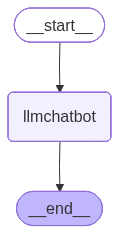

In [9]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:
response=graph.invoke({"messages":"Hi"})

In [11]:
response["messages"][-1].content

'<think>\nOkay, the user said "Hi". I need to respond appropriately. Since it\'s a greeting, I should reply with a friendly greeting. Maybe add an emoji to keep it warm. Let me check if there\'s anything else they might need. They might want to start a conversation, so I should offer help. Something like "Hello! 😊 How can I assist you today?" That should work.\n</think>\n\nHello! 😊 How can I assist you today?'

In [12]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

<think>
Okay, the user started with a greeting, so I need to respond politely. They asked "Hi How are you?" which is a common way to start a conversation. I should acknowledge their greeting and offer a friendly reply. Maybe add an emoji to keep it warm and approachable. Also, since they might want to continue the conversation, I should ask how they're doing. Keep it simple and open-ended to encourage them to share more if they want to. Make sure the tone is cheerful and welcoming.
</think>

Hello! 🌟 I'm doing great, thanks for asking! How are you feeling today? I'd love to hear how your day is going! (•̀ᴗ•́)و


### Chatbot With Tool

In [13]:
from dotenv import load_dotenv
load_dotenv()

from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)

result = tool.invoke("What is LangGraph")
print(result)

{'query': 'What is LangGraph', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph', 'title': 'What is LangGraph - GeeksforGeeks', 'content': "LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. LangChain uses a straightforward step-by-step pipeline where each task follows a fixed sequence from input to output while LangGraph allows flexible workflows with branching and parallel steps, making it better suited for complex, decision-based applications. ## Workflow of LangGraph. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. Here's a step by step interpretation of the flow:. In this example we’ll learn how to create a b

In [14]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [15]:
tools=[tool,multiply]

In [16]:
llm_with_tool=llm.bind_tools(tools)

In [17]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001C803146990>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001C803147390>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for com

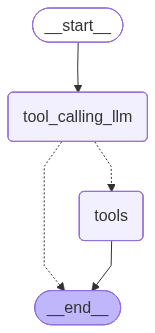

In [18]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))



In [19]:
response=graph.invoke({"messages":"What is the recent ai news"})

In [20]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.tiktok.com/@parthknowsai/video/7654565305712250142", "title": "General AI tools beat expensive domain specific once #ai ...", "content": "Recent news shows CEOs going all out calling LLMs sentient and past human intelligence. In this youtube video I break it down #ai #learnontiktok #chatgpt", "score": 0.735737, "raw_content": null}, {"url": "https://www.foxnews.com/video/6399127210112", "title": "AI in the classroom: How AI will impact education moving ...", "content": "A recent Fox News poll highlights changing perceptions as 52% of voters now consider Big Tech a greater threat to the U.S. future compared to Big Government\'s", "score": 0.5611433, "raw_content": null}], "response_time": 1.76, "request_id": "be4e9749-308f-4bd5-8ded-9bae208f4a1d"}'

In [21]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (e9gasb30g)
 Call ID: e9gasb30g
  Args:
    query: recent AI news
    time_range: week
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.tiktok.com/@parthknowsai/video/7654565305712250142", "title": "General AI tools beat expensive domain specific once #ai ...", "content": "Recent news shows CEOs going all out calling LLMs sentient and past human intelligence. In this youtube video I break it down #ai #learnontiktok #chatgpt", "score": 0.735737, "raw_content": null}, {"url": "https://www.foxnews.com/video/6399127210112", "title": "AI in the classroom: How AI will impact education movi

In [22]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (xe5t1cezd)
 Call ID: xe5t1cezd
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [23]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (f5hppxqs5)
 Call ID: f5hppxqs5
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
  multiply (28ve5dyq0)
 Call ID: 28ve5dyq0
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.crescendo.ai/news/latest-ai-news-and-updates", "title": "The Latest AI News and Breakthroughs That Matter Most | News", "content": "Source: WION News\n\n### (AI News) Battery Breakthroughs Will Lessen AI's Demand on the Electricity Grid\n\nDate: June 12, 2026\n\nSummary: The Washington Post editorial board argues that battery innovations will ease 

### ReAct Agent Architecture

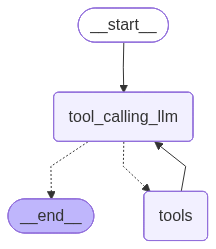

In [24]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (pkgjx3aqb)
 Call ID: pkgjx3aqb
  Args:
    query: recent ai news
    time_range: week
    topic: general
  multiply (wzfkva0e8)
 Call ID: wzfkva0e8
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.tiktok.com/@parthknowsai/video/7654565305712250142", "title": "General AI tools beat expensive domain specific once #ai ...", "content": "Recent news shows CEOs going all out calling LLMs sentient and past human intelligence. In this youtube video I break it down #ai #learnontiktok #chatgpt", "score": 0.74541736, "raw_content": null}, {"url": "https://www.

## Adding Memory In Agentic Graph

In [26]:
response=graph.invoke({"messages":"Hello my name is Nasreen"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Nasreen
================================== Ai Message ==================================

Hello Nasreen! How can I assist you today?


In [27]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don't have access to your name or personal information. If you'd like me to know your name, please share it with me directly!


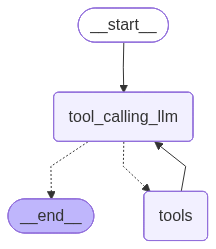

In [45]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [46]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Nasreen"},config=config)

response



{'messages': [HumanMessage(content='Hi my name is Nasreen', additional_kwargs={}, response_metadata={}, id='6a63dea8-3d7a-4273-a95e-85edee1ff444'),
  AIMessage(content='Hello Nasreen! How can I assist you today?', additional_kwargs={'reasoning_content': 'Okay, the user introduced themselves as Nasreen. I need to respond appropriately. Since there\'s no specific query here that requires using the tools provided, my best bet is to just acknowledge their introduction and offer assistance. Let me make sure I don\'t call any functions here because there\'s nothing to process. I\'ll keep it friendly and open-ended.\n\nSo, the response should be something like, "Hello Nasreen! How can I assist you today?" That\'s straightforward and invites them to ask a question or share more. I need to avoid using any tool calls since there\'s no actionable request. Just a simple, polite reply.\n'}, response_metadata={'token_usage': {'completion_tokens': 143, 'prompt_tokens': 1787, 'total_tokens': 1930, 'co

In [47]:
response['messages'][-1].content

'Hello Nasreen! How can I assist you today?'

In [48]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Your name is Nasreen. How can I assist you today?


In [49]:
response=graph.invoke({"messages":"Hey do you remember mmy name"},config=config)

print(response['messages'][-1].content)

Yes, I remember your name is Nasreen! How can I assist you today? 😊


### Streaming

In [33]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [34]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

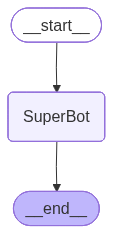

In [35]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [36]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='f4a67190-319d-4e4e-8125-7d42ca28c248'),
  AIMessage(content="<think>\nOkay, the user is Krish and he likes cricket. Let me start by acknowledging his name and interest. I should respond in a friendly and enthusiastic way. Maybe ask him about his favorite team or player. That would show I'm interested in his hobbies. Also, maybe suggest some topics related to cricket that we can discuss. Keep the tone positive and open-ended. Let me make sure the response is concise but engaging.\n</think>\n\nHi Krish! 👋 That's awesome—you've got great taste in sports! Cricket is such an exciting game. Do you follow any particular team or player? I'd love to hear what you enjoy most about the sport! 🏏 #CricketChampion #SportsEnthusiast", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 148, 'prompt_tokens': 18, 'total_tokens': 166, 'completion_time': 0

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

In [51]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Nasreen And I like cooking"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, let's see. The user's name is Nasreen and she likes cooking. She's mentioned this twice now. The previous interactions had Krish talking about cricket, and now a new user, Nasreen, is stepping in with her interest in cooking.\n\nFirst, I need to make sure the response is personalized and engaging. Since she's new to the conversation, a warm welcome is important. I should acknowledge her name and her interest in cooking. \n\nThe user might be looking for a friendly chat about cooking, maybe to share recipes or get inspiration. I should ask open-ended questions to encourage her to talk more. Maybe ask about her favorite cuisines or dishes she enjoys cooking. \n\nAlso, since there was another user before with a different interest, I need to make sure the transition is smooth and doesn't mix up the previous conversation. The response should focus solely on Nasreen and her cooking interest without referencing Krish unless necessar

In [55]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Nasreen And I like cooking"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='0957ff39-985b-409a-a47f-08f64ec9139e'), AIMessage(content="<think>\nOkay, the user introduced themselves as Krish and mentioned they like cricket. Since they're new, I should respond in a friendly and welcoming way. I'll start by thanking them for sharing their interest. Cricket is a great topic, so I can ask a follow-up question to encourage further conversation. Maybe something like asking which team they support or if they play the game themselves. That way, I can engage them more and learn more about their preferences. I'll keep the tone positive and open to make them feel comfortable to continue the chat.\n</think>\n\nHi Krish! 😊 Welcome! Cricket is an amazing sport—I'm glad to hear you enjoy it! Do you have a favorite team or cricketer? Also, do you play the game yourself, or are you more of a passionate spectator? 🏏", additional_kwargs={}, response_metadat

In [56]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Nasreen And I like cooking"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, let's see. The user's name is Nasreen, and she likes cooking. I need to respond in a friendly and engaging way. First, I should acknowledge her name and express interest in her hobby. Maybe ask her what kind of cuisine she enjoys cooking or if she has any favorite dishes. I should also consider if she's into baking, cooking techniques, or experimenting with new recipes. It's good to show enthusiasm and maybe ask if she has any tips or wants to share a recipe. I should keep the tone warm and inviting to encourage her to talk more about her passion. Let me make sure to use emojis related to cooking to keep it light and relatable. Also, check for any previous interactions to maintain consistency, but since this is a new conversation, I just need to start fresh. Alright, that should cover it.\n</think>\n\nHi Nasreen! 🍳 Hello from the world of flavors and aromas—love that you enjoy cooking! What’s your favorite cuisine to cook? Do

In [57]:
for chunk in graph_builder.stream({'messages':"I also like roaming"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='18bde2ce-08bb-439a-9c1b-d44781cb2718'), AIMessage(content="<think>\nOkay, the user introduced himself as Krish and mentioned he likes cricket. I should respond warmly to his introduction. First, greet him and acknowledge his interest in cricket. Maybe ask a question to encourage a deeper conversation about cricket. Keep the tone friendly and open-ended so he feels comfortable sharing more. Also, check if there's anything specific he wants to discuss about cricket. Avoid making the response too long but make sure it's engaging. Maybe mention a recent cricket event or a popular team to relate to his interest. Let me put that together.\n</think>\n\nHi Krish! Nice to meet you. 🏏 I love that you're a cricket fan—what's your favorite part about the game? Do you follow a particular team or player closely? Let me know if you'd like to chat more about matches, strategies,

In [58]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Nasreen And I like cooking"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Nasreen And I like cooking']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ef94f-39f7-7121-87e4-f703be20c182', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='fe682bdc-fa23-4bf2-a2b7-30474f733d7f'), AIMessage(content="<think>\nOkay, the user is Krish and he likes to play cricket. Let me start by acknowledging his name and his interest. I should respond in a friendly and engaging way. Maybe ask him about his favorite position in cricket or a memorable game he's played. That would help keep the conversation going. Also, I should make sure to use proper grammar and keep it natural. Let me check if there's anything else I need to add. No, this should be good. Let me put it all together now.\n</think>\n\n